# Pymob  Introduction
## Overview
**Pymob** is a Python-based platform for parameter estimation across a wide range of models. It abstracts repetitive tasks in the modeling process so that you can focus on building models, asking questions to the real world and learn from observations. <br>
The idea of pymob originated from the frustration with fitting complex models to complicated datasets (missing observations, non-uniform data structure, non-linear models, ODE models). In such scenarios a lot of time is spent matching observations with model results. <br>
One of Pymob’s key strengths is its streamlined model definition workflow. This not only simplifies the process of building models but also lets you apply a host of advanced optimization and inference algorithms, giving you the flexibility to iterate and discover solutions more effectively. <br>

### What's the focus of this introduction?
This introduction will give you an overview of the pymob package and an easy example on how to use it. After, you can explore more advanced tutorials and deepen your pymob kowledge. <br> 
First the general structure of the pymob package will be explained. You will get to know the function of the components. Subsequentenly you will get instructions to use pymob for your first parameter estimation with a simple example. 

### How pymob is structured:
Here  you can see the structure of the structure of pymob package: <br>
![Structure of the pymob package](./figures/pymob_overview.png) <br>
The Pymob package consists of several elements: 


1) __Simulation__ <br>
First, we need to initialize a Simulation object by calling the {class}`pymob.simulation.SimulationBase` class from the simulation module.   
Optionally, we can configure the simulation object with {attr}`pymob.simulation.SimulationBase.config.case_study.name` = "linear-regression", {attr}`pymob.simulation.SimulationBase.config.case_study.scenario` = "test" and many more options. 

2) __Model__ <br>
The model is a python function you define. With the model you try to describe the data you observed. A classical model is, for example, the Lotka-Volterra model to describe the interactions of predators and prey. In the tutorial today, the model will be a simple linear function. <br>
The model will be added to the simualtion by using {class}`pymob.simulation.SimulationBase.model`

3) __Observations__ <br>
The obseravtions are the data points, to which we want to fit our model. The observation data needs to be an `xarray.Dataset` ([learn more here](https://docs.xarray.dev/en/stable/getting-started-guide/quick-overview.html)).  
We assign it to our Simulation object by  {attr}`pymob.simulation.SimulationBase.observations`.  
{attr}`pymob.simulation.SimulationBase.config.data_structure` will give us some information about the layout of our data.

4) __Solver__ <br>
A solver is required for many models e.g. models that contain differential equations. Solvers in pymob are callables that need to return a dictionary of results mapped to the data variables. <br>
The solver is assigned to the Simulation object by {class}`pymob.simulation.SimulationBase.solver`. <br>
These solvers are currently implemented in pymob: 
    - analytic module
        - solve_analytic_1d
    - base module 
        - curve_jumps
        - jump_interpolation
        - mappar
        - radius_interpolation
        - rect_interpolation
        - smoothed_interpolation
    - diffrax module
        - JaxSolver
    - scipy module
        - solve_ivp_1d

The documentation can be found [here](https://pymob.readthedocs.io/en/stable/api/pymob.solvers.html) 

5) __Inferer__ <br>
    The inferer serves as the parameter estimator. Pymob provides various backends. You can find detailed information [here](https://pymob.readthedocs.io/en/stable/user_guide/framework_overview.html). <br>
    Currently, supported inference backends are:
    * interactive (interactive backend in jupyter notebookswith parameter sliders)
    * numpyro (bayesian inference and stochastic variational inference)
    * pyabc (approximate bayesian inference)
    * pymoo (experimental multi-objective optimization)

6) __Evaluator__ <br>
The Evaluator is an instance to manage model evaluations. It sets up tasks, coordinates parallel runs of the simulation and keeps track of the results from each simulation or parameter inference process.

7) __Config__ <br>
Pymob uses `pydantic` models to validate configuration files, with the configuration organized into separate sections. You can modify these configurations either by editing the files before initializing a simulation from a config file, or directly within the script. During parameter estimation setup, all configuration settings are stored in a config object, which can later be exported as a `.cfg` file.








### Let's get started 🎉
You will need several packages during this introduction:

In [ ]:
# imports from pymob
from pymob.simulation import SimulationBase
from pymob.sim.solvetools import solve_analytic_1d
from pymob.sim.config import Param

# other imports
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import os
from numpy import random

In the following tutorial, you’ll notice some import statements included as comments. These are provided to indicate which package is required for each step.

## Generate artificial data

In the real world, you will have measured a dataset. For demonstration, we generate some artifical data. Later we will fit the model to our artifical data. <br>
$y_{obs}$ represents the observation data over the time $t$ [0, 10].  

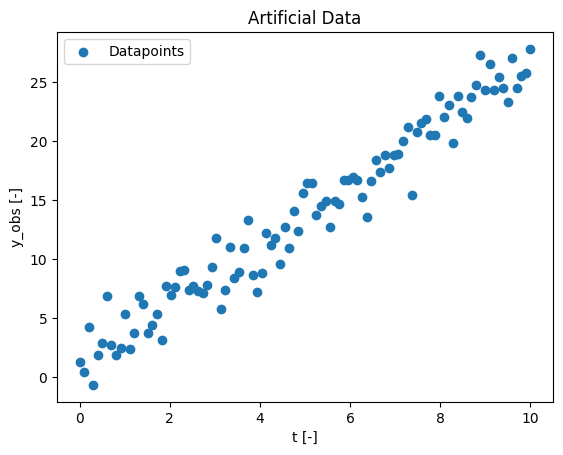

In [ ]:
# Parameter for the artificial data generation
rng = np.random.default_rng(seed=1)  # for reproducibility
slope = rng.uniform(1,4)
intercept = 1.0
num_points = 100
noise_level = 1.7

# generating x-values
x = np.linspace(0, 10, num_points)

# generating y-values with noise
noise = rng.normal(0, noise_level, num_points)
y_obs = slope * x + intercept + noise

data = np.array(y_obs)

# visualising our data
plt.scatter(x, y_obs, label='Datapoints')
plt.xlabel('t [-]')
plt.ylabel('y_obs [-]')
plt.title('Artificial Data')
plt.legend()
plt.show()

Above you can see you're generated artificial data. At the moment it's stored in a normal array as you can see below: 

In [3]:
# our artificial data is now in the variable data
print(data)

[ 0.44668493 -1.05339278  2.88210883  0.54770906  4.90974856  3.1063565
  4.1153076   3.60259822  1.69447086  6.11825235  2.56857373  6.38476746
  2.93053129  3.59011671  3.42634276  6.02443788  5.72637654  3.22811334
  4.84727615  3.9733141   5.65347452  5.50991143  8.54505759  5.6833806
  7.65710427  5.64452999  7.10133308  7.00760147  6.75841725  9.37537888
  8.14045588  6.85651275 10.12309432 11.08196899 11.52097808  7.51548696
  8.0297615  10.85079118 12.93975746 10.2212721  16.0213019  14.17261046
 11.14047691 11.05711712 12.680791   10.39508488 13.02588009 14.54587264
 11.06522809 15.05341466 15.88021161 13.5149888  12.35195892 13.75650635
 14.42424165 11.76829229 14.74964692 16.40062315 15.11131069 15.20300216
 14.99451106 18.36247128 17.63770869 18.36809463 15.54230347 15.94216816
 19.04781969 17.34864417 18.07014272 18.20120197 19.87433198 18.7962511
 18.7543702  18.2084891  23.12944126 20.59857353 18.77284008 23.88329856
 23.3321688  23.02580195 23.21747082 23.25404914 26.31

The pymob package operates with `xarray.Dataset`. We avoid most of the mess by using `xarray` as a common input/output format. So we have to transform our data into a `xarray.Dataset`.

In [4]:
obs_data = xr.DataArray(data, dims = ("t"), coords={"t": x}).to_dataset(name="data") 

Note: If you want to rename your data-dimension you have to change every {class}`sim.config.data_structure.data` to the new name!

It can be helpful to look at the data befor going forward, especially if you never worked with *xarray Datasets*. At the section 'Data variables' you'll find the data you just generated. 

In [5]:
obs_data

<xarray.Dataset>
Dimensions:  (t: 100)
Coordinates:
  * t        (t) float64 0.0 0.101 0.202 0.303 0.404 ... 9.697 9.798 9.899 10.0
Data variables:
    data     (t) float64 0.4467 -1.053 2.882 0.5477 ... 28.74 25.67 23.97 30.7

## Initialize a simulation
First, we initialize an object of the class simulation. This is the center of the whole package and will manage all processes from now on. <br>
In pymob a Simulation object is initialized by calling the {class}`pymob.simulation.SimulationBase` class from the simulation module.

In [6]:
#from pymob.simulation import SimulationBase

sim = SimulationBase()

```{admonition} Configuring the simulation
:class: note
Optionally, we can configure the simulation at this stage with 
`sim.config.case_study.name = "linear-regression"`, `sim.config.case_study.scenario = "test"`, and many more options. 
```
Case studies are a principled approach to the modelling process. In essence, they are a simple template that contains building blocks for model and names and stores them in an intuitive and reproducible way. [Here](https://pymob.readthedocs.io/en/stable/user_guide/case_studies.html#configuration) you'll find some additional information on case studies. <br>

At the moment, it is sufficient to only create a simulation object without making any further configurations.

## Define a model 

Now the model needs to be defined. In Pymob, every model is represented as a Python function. Here, you’ll specify the model whose parameters will be estimated.

In this tutorial, we’ll use linear regression as our example, since it’s the simplest form of modeling.

In [7]:
# definition of the model: 
def linreg(t, a, b):
    return a + t * b

So we assume that this model describes our data well. So we add it to the simulation by

In [8]:
sim.model = linreg


## Defining a solver

As described above: A solver is required for many models. So we define a solver by {class}`pymob.simulation.SimulationBase.solver`. <br>
In our case the model gives the exact solution of the model. Therefore, we choose `solve_analytic_1d`. An overwiev of the solvers currently implemented in pymob can be found at the beginning of this tutorial [here](#how-pymob-is-structured).

In [9]:
# from pymob.sim.solvetools import solve_analytic_1d
sim.solver = solve_analytic_1d

## The pymob magic

So far we have not done anything special. Pymob exists, because wrangling dimensions of input and output data, nested data-structures, missing data is painful. <br>

Now we add our data, which is already transformed into a *xarray Dataset*, by using {attr}`pymob.simulation.SimulationBase.observations`.

In [10]:
# import xarray as xr

sim.observations = obs_data

MinMaxScaler(variable=data, min=-1.0533927803793315, max=30.700852250682072)


C:\Users\ameli\OneDrive\Dokumente\01_Uni\04_Jobs\01_TKTD\pymob\pymob\simulation.py:303: UserWarning: `sim.config.data_structure.data = Datavariable(dimensions=['t'] min=-1.0533927803793315 max=30.700852250682072 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.data = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(


This worked 🎉 {attr}`pymob.simulation.SimulationBase.config.data_structure` will now give us some information about the layout of our data, which will handle the data transformations in the background.

In [11]:
sim.config.data_structure

Datastructure(data=DataVariable(dimensions=['t'], min=-1.0533927803793315, max=30.700852250682072, observed=True, dimensions_evaluator=None))

```{admonition} What happens when we assign a Dataset to the observations attribute?
:class: hint

Debug into the function and discover what happens!
```

We can give `pymob` additional information about the data structure of our observations and intermediate (unobserved) variables that are simulated. This can be done with {attr}`sim.config.data_structure.y` = `DataVariable(dimensions=["x"])`.
These information can be used to switch the dimensional order of the observations or provide data variables that have differing dimensions from the observations, if needed. But if the dataset is ordinary, simply setting {attr}`pymob.simulation.SimulationBase.observations` property with a `xr.Dataset` will be sufficient.

```{admonition} Scalers
:class: note
We also notice a mysterious Scaler message. This tells us that our data variable has been identified and a scaler was constructed, which transforms the variable between [0, 1]. This has no effect at the moment, but it can be used later. Scaling can be powerful to help parameter estimation in more complex models.
```

## Parameterizing a model

Parameters are specified via the `FloatParam` or `ArrayParam` class. Parameters can be marked free or fixed depending on whether they should be variable during an optimization procedure. <br>

In this tutorial we want to fit the parameter $b$ and assume that we know parameter $a$: <br>
* The parameter $a$ is set as fixed (`free = False`), meaning its value is known and will not be estimated during optimization.
* The parameter $b$ is marked as free (`free = True`), allowing it to be optimized to fit our data. As an initial guess, we assume $b = 3$.


In [ ]:
#from pymob.sim.config import Param
sim.config.model_parameters.a = Param(value=0, free=False)
sim.config.model_parameters.b = Param(value=3, free=True)

# this makes sure the model parameters are available to the model.
sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

To make the parameters available to the simulation one has to use {attr}`sim.model_parameters["parameters"]` = {attr}`sim.config.model_parameters.value_dict`. This step is particularly important for all fixed parameters.

{attr}`pymob.simulation.SimulationBase.model_parameters` is a dictionary that stores the input data for the model. By default, it includes the keys `parameters`, `y0`, and `x_in`. For our analytic model, we only need the `parameters` key. In situations where initial values for variables are required, you can provide them using {attr}`pymob.simulation.SimulationBase.model_parameters["y0"]` = ... .

For example, when working with a Lotka-Volterra model, you would specify the initial conditions for the predator and prey populations with `y0`. For more details on such use cases, please refer to the advanced tutorial.

```{admonition} generating input for solvers
:class: note
A helpful function to generate `y0` or `x_in` from observations is `SimulationBase.parse_input`, combined with settings of `config.simulation.y0`
```

In [13]:
sim.model_parameters['parameters']

{'a': 0.0, 'b': 3.0}

## Running the model 🏃

The model is prepared with a parameter set and ready to be executed. With {class}`pymob.simulation.SimulationBase.dispatch_constructor()`, everything is prepared for the run of the model. It initiaizes an `evaluator`, makes preliminary calculations and checks. 

ℹ️ What does the dispatch constructor do?: <br>
Behind the scenes, the dispatch constructor assembles a lightweight {class}`pymob.simulation.SimulationBase.evaluator` object from the Simulation object, that takes the least necessary amount of information, runs it through some dimension checks, and also connects it to the specified solver and initializes it. The purpose of the dispatch constructor is manyfold: <br>
By executing the entire overhead of a model evaluation and packing it into a new {class}`pymob.simulation.SimulationBase.evaluator` instance {meth}`pymob.simulation.SimulationBase.dispatch_constructor()` to make single model evaluations as fast as possible and allow parallel evaluations, because each evaluator created by {meth}`pymob.simulation.SimulationBase.dispatch()` is it's a fully independent model instance with a separate set of parameters that can be solved.
Evaluators store the raw output from a simulation and can generate an xarray object from it that corresponds to the data-structure of the observations with the {attr}`pymob.simulation.SimulationBase.evaluator.results` property. This automatically aligns simulations results with observations, for simple computation of loss functions.

For the parameter estimation it is not necessary to run the model, but it can be helpfull. By using {meth}`pymob.simulation.SimulationBase.dispatch()` all the parameters with the setting `free=True` get fixed. Therefore, we have to fix parameter $b$. 

*Try changing the value of $b$ and see what effect it has on the next steps?* <br>

**{meth}`pymob.simulation.SimulationBase.dispatch_constructor()` should be executed every time you change something in your simulation settings, even if you don't run the model.** <br>

In [14]:
# put everything in place for running the simulation
sim.dispatch_constructor()

# run
evaluator = sim.dispatch(theta={"b":3}) # makes sure that the parameter b is set to 3
evaluator()
evaluator.results

C:\Users\ameli\OneDrive\Dokumente\01_Uni\04_Jobs\01_TKTD\pymob\pymob\simulation.py:552: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['a+t*b'] from the source code. Setting 'n_ode_states=1.
  warnings.warn(


<xarray.Dataset>
Dimensions:  (t: 100)
Coordinates:
  * t        (t) float64 0.0 0.101 0.202 0.303 0.404 ... 9.697 9.798 9.899 10.0
Data variables:
    data     (t) float64 0.0 0.303 0.6061 0.9091 1.212 ... 29.09 29.39 29.7 30.0

This returns a dataset which is of the exact same shape as the observation dataset, plus intermediate variables that were created during the simulation, if they are tracked by the solver.

Although this API seems to be a bit clunky, it is necessary, to make sure that simulations that are executed in parallel are isolated from each other.


## Estimating parameters 

We are almost set to infer the parameters of the model. We add another parameter to also estimate the error of the parameters, We use a lognormal distribution for it. We also specify an error model for the distribution. This will be 

$$y_{obs} \sim Normal (y, \sigma_y)$$

Further we also have to make some assumptions for the parameter $b$ which we want to fit. First, we have to define the prior function from which we draw the parameter values during the parameter estimation. Additionally, we set the `min` and `max` values for our parameters. This can also be done in one step,  as can be seen for the error-model parameter `sigma_y`.

In [15]:
sim.config.model_parameters.b.prior = "lognorm(scale=1,s=1)"
sim.config.model_parameters.b.min = -5
sim.config.model_parameters.b.max = 5

#construction the error model
sim.config.model_parameters.sigma_y = Param(free=True , prior="lognorm(scale=1,s=1)", min=0, max=1)

sim.config.error_model.data = "normal(loc=data,scale=sigma_y)"

As `sigma_y` is not a fixed parameter, the new parameter does not have to be passed to the simulation class.

In [16]:
sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict
sim.model_parameters['parameters']

{'a': 0.0, 'b': 3.0, 'sigma_y': 0.0}

### Manual estimation

First, we try estimating the parameters by hand. For this we have a simple interactive backend. <br>
Note that changing sigma_y has no effect on the model fit because sigma_y is only used for the error model.

In [ ]:
from matplotlib import pyplot as plt
def plot(results: xr.Dataset):
    obs = sim.observations

    SSE = ((results.data - obs.data) ** 2).sum(dim="t") #calculating the sum of squared errors

    fig, ax = plt.subplots(1,1)
    ax.plot(results.t, results.data, lw=2, color="black")
    ax.plot(obs.t, obs.data, ls="", marker="o", color="tab:blue", alpha=.5)
    ax.set_xlim(-1,12)
    ax.set_ylim(-1,30)
    ax.text(0.05, 0.95, f"SSE={np.round(SSE.values, 2)}", transform=ax.transAxes, ha="left", va="top")

In [28]:
sim.plot = plot
sim.interactive()

### Estimating parameters and uncertainty with MCMC

Of course this example is very simple, we can in fact optimize the parameters perfectly by hand. But just for the fun of it, let's use *Markov Chain Monte Carlo* (MCMC) to estimate the parameters, their uncertainty and the uncertainty in the data. <br>

The inferer serves as the parameter estimator. Different inferer are implemented in numpy and can be found at the beginning of the tuorial and in the API. The method for the parameter estimation is defined by using {meth}`pymob.simulation.SimulationBase.set_inferer()`. This automatically translates the pymob data in the format of the selected inferer. Numpyro additionally needs a kernel. To start the estimation you use {meth}`pymob.simulation.SimulationBase.inferer.run()`.


*Note that other methods often don't need a kernel.*


```{admonition} numpyro distributions
:class: warning
Currently only few distributions are implemented in the numpyro backend. This API will soon change, so that basically any distribution can be used to specifcy parameters. 
```

Finally, we let our inferer run the paramter estimation procedure with the numpyro backend and a NUTS kernel. This does the job in a few seconds. <br>


In [19]:
sim.dispatch_constructor() # important to call this before running the inferer

sim.set_inferer("numpyro")
sim.inferer.config.inference_numpyro.kernel = "nuts"
sim.inferer.run()

sim.inferer.idata.posterior

Jax 64 bit mode: False
Absolute tolerance: 1e-07


C:\Users\ameli\OneDrive\Dokumente\01_Uni\04_Jobs\01_TKTD\pymob\pymob\inference\numpyro_backend.py:552: UserWarning: Model is not rendered, because the graphviz executable is not found. Try search for 'graphviz executables not found' and the used OS. This should be an easy fix :-)
  warnings.warn(


Trace Shapes:      
 Param Sites:      
Sample Sites:      
       b dist     |
        value     |
 sigma_y dist     |
        value     |
data_obs dist 100 |
        value 100 |


sample: 100%|██████████| 3000/3000 [00:07<00:00, 420.73it/s, 3 steps of size 7.38e-01. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      2.73      0.03      2.73      2.68      2.78   1645.00      1.00
   sigma_y      1.80      0.13      1.79      1.60      2.02   1113.95      1.00

Number of divergences: 0


<xarray.Dataset>
Dimensions:  (chain: 1, draw: 2000)
Coordinates:
  * chain    (chain) int32 0
  * draw     (draw) int32 0 1 2 3 4 5 6 7 ... 1993 1994 1995 1996 1997 1998 1999
    cluster  (chain) int32 0
Data variables:
    b        (chain, draw) float32 2.783 2.69 2.673 2.697 ... 2.706 2.696 2.709
    sigma_y  (chain, draw) float32 1.704 2.01 1.895 1.962 ... 1.627 2.016 1.74
Attributes:
    created_at:     2025-06-23T08:31:52.794154+00:00
    arviz_version:  0.20.0

We can inspect our estimates and see that the parameters are well esimtated by the model. Note that we only get an estimate for `b`. This is because earlier we set the parameter `a` with the flag `free=False` this effectively excludes it from estimation and uses the default value, which was set to the true value `a=0`. <br>

The `mean`of `b` is the value of the estimated parameter. It should be the same or close to estimation you did manually. The `sigma_y` is the mean error of this estimation.

### Plot the results

Pymob provides a very basic utility for plotting posterior predictions. We see that the mean is a perfect fit and also that the uncertainty in the data is correctly displayed. Fantstic 🎉

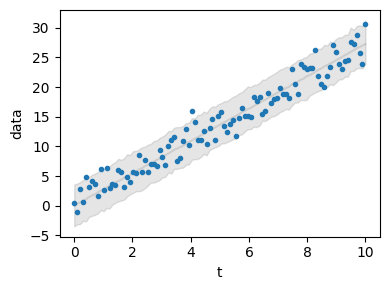

In [20]:
sim.config.simulation.x_dimension = "t"
sim.posterior_predictive_checks(pred_hdi_style={"alpha": 0.1})


```{admonition} Customize the posterior predictive checks
:class: hint
You can explore the API of {class}`pymob.sim.plot.SimulationPlot` to find out how you can work on the default predictions. Of course you can always make your own plot, by accessing {attr}`pymob.simulation.inferer.idata` and {attr}`pymob.simulation.observations`
```

### Report the results
The command {meth}`pymob.simulation.SimulationBase.report()` can be used to generate an automated report. The report can be configured with options in {meth}`pymob.simulation.SimulationBase.config.report()`.

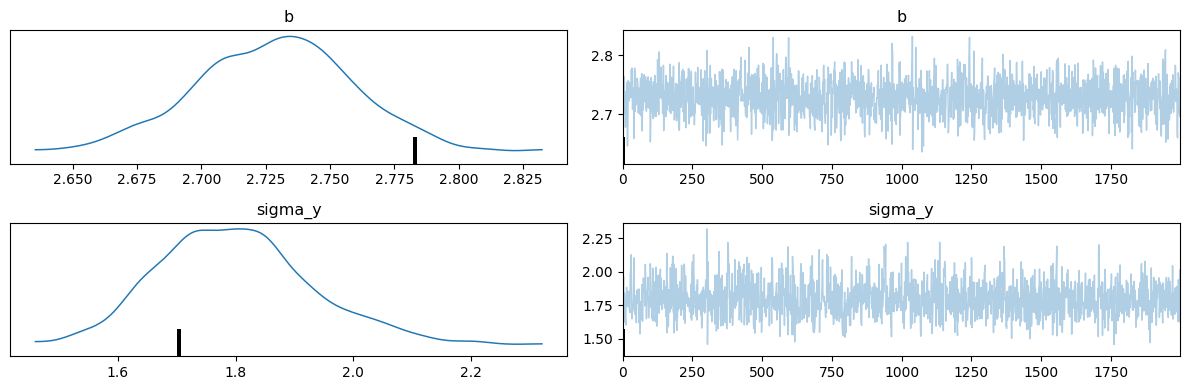

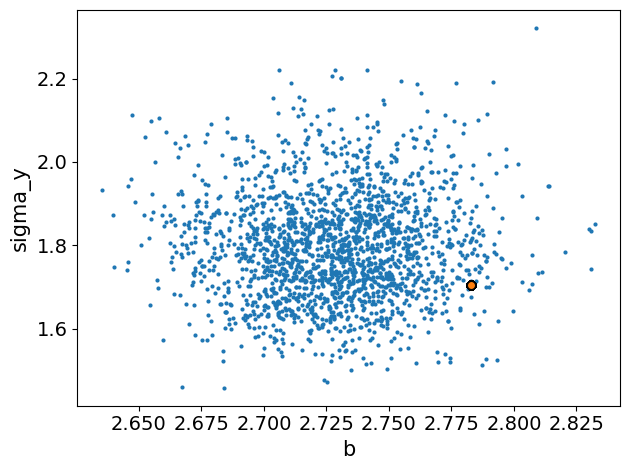

In [21]:
sim.report()


## Exporting the simulation and running it via the case study API

After constructing the simulation, all settings of the simulation can be exported to a comprehensive configuration file, along with all the default settings. This is as simple as 

In [22]:
import os
sim.config.case_study.name = "quickstart"
sim.config.case_study.scenario = "test"
sim.config.create_directory("scenario", force=True)
sim.config.create_directory("results", force=True)

# usually we expect to have a data directory in the case
os.makedirs(sim.data_path, exist_ok=True)
sim.save_observations(force=True)
sim.config.save(force=True)

Scenario directory exists at 'c:\Users\ameli\OneDrive\Dokumente\01_Uni\04_Jobs\01_TKTD\pymob_new\pymob\docs\source\user_guide\case_studies\quickstart\scenarios\test'.
Results directory exists at 'c:\Users\ameli\OneDrive\Dokumente\01_Uni\04_Jobs\01_TKTD\pymob_new\pymob\docs\source\user_guide\case_studies\quickstart\results\test'.


The simulation will be saved to the default path (`CASE_STUDY/scenarios/SCENARIO/settings.cfg`) or to a custom file path specified with the `fp` keyword. `force=True` will overwrite any existing config file, which is the reasonable choice in most cases.

From there on, the simulation is (almost) ready to be executable from the commandline.

### Commandline API

The commandline API runs a series of commands that load the case study, execute the {meth}`pymob.simulation.SimulationBase.initialize` method and perform some more initialization tasks, before running the required job.

+ `pymob-infer`: Runs an inference job e.g. `pymob-infer --case_study=quickstart --scenario=test --inference_backend=numpyro`. While there are more commandline options, these are the two required 